In [96]:
import pandas as pd
import numpy as np

In [97]:
df = pd.read_csv('car data.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [98]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [99]:
df=df.drop(columns=['Present_Price','Selling_type','Transmission','Owner'])

In [100]:
df

,Car_Name,Year,Selling_Price,Driven_kms,Fuel_Type
0,ritz,2014,3.35,27000,Petrol
1,sx4,2013,4.75,43000,Diesel
2,ciaz,2017,7.25,6900,Petrol
3,wagon r,2011,2.85,5200,Petrol
4,swift,2014,4.60,42450,Diesel
...,...,...,...,...,...
296,city,2016,9.50,33988,Diesel
297,brio,2015,4.00,60000,Petrol
298,city,2009,3.35,87934,Petrol
299,city,2017,11.50,9000,Diesel


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Driven_kms     301 non-null    int64  
 4   Fuel_Type      301 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.9+ KB


<Axes: >

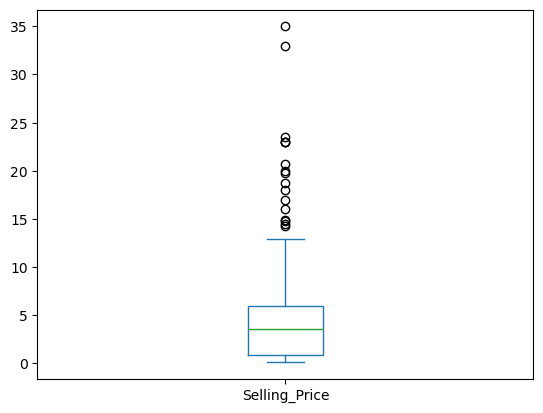

In [102]:
df['Selling_Price'].plot(kind='box')

<Axes: ylabel='Density'>

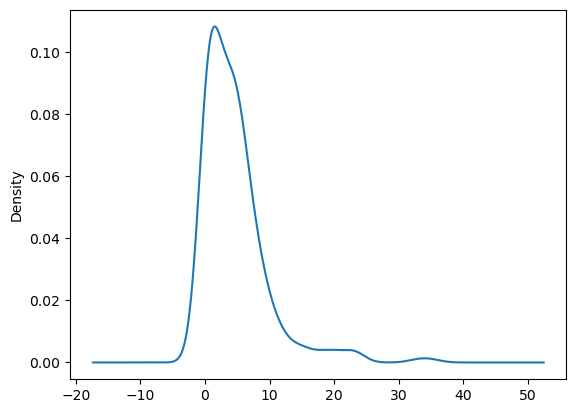

In [103]:
df['Selling_Price'].plot(kind='kde')

In [104]:
df[df['Selling_Price'] > 12]


,Car_Name,Year,Selling_Price,Driven_kms,Fuel_Type
50,fortuner,2012,14.90,104707,Diesel
51,fortuner,2015,23.00,40000,Diesel
52,innova,2017,18.00,15000,Diesel
53,fortuner,2013,16.00,135000,Diesel
59,fortuner,2014,19.99,41000,Diesel
62,fortuner,2014,18.75,78000,Diesel
63,fortuner,2015,23.50,47000,Diesel
64,fortuner,2017,33.00,6000,Diesel
66,innova,2017,19.75,11000,Petrol
69,corolla altis,2016,14.25,12000,Petrol


### extracting training data

In [105]:
x = df[['Car_Name','Year','Driven_kms','Fuel_Type']]
y = df['Selling_Price']

### applying train test split

In [106]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [107]:
from sklearn.linear_model import LinearRegression

In [108]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

### hotencoder

In [109]:
ohe = OneHotEncoder()
ohe.fit(x[['Car_Name','Fuel_Type']])

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


### creating a column transformation to transform categorical columns

In [110]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['Car_Name','Fuel_Type']),remainder='passthrough')

In [111]:
lr = LinearRegression()
## pipeline
pipe=make_pipeline(column_trans,lr)

In [112]:
### fitting the model

pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)

## checking R2 score
r2_score(y_test,y_pred)

0.3910544212219159

In [113]:
scores=[]
for i in range(1000):
    x_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))


In [114]:
np.argmax(scores)

np.int64(481)

In [115]:
accuracy = scores[np.argmax(scores)]

In [116]:
print("car price pediction !!")
name = input("enter car name")
year = int(input("enter  year"))
driven = int(input("enter driven km"))
fuel = input("enter fuel type")

price = pipe.predict(pd.DataFrame(columns=x_test.columns,data=np.array([name,year,driven,fuel]).reshape(1,4)))

print("car price is : ",price)
print("Accuract : ",accuracy)


car price pediction !!
car price is :  [18.08880217]
Accuract :  0.9358869310288842


In [117]:
pipe.predict(pd.DataFrame(columns=x_test.columns,data=np.array([name,year,driven,fuel]).reshape(1,4)))

array([18.08880217])

In [118]:
# print("car price is : ",price)
# print("Accuract : ",accuracy)